## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [1]:
import pandas as pd
import geopandas as gpd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
from fuzzywuzzy import fuzz
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_ID = 'EL52'

In [3]:
dataset_monthly = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2009_2023.csv", encoding = enc)
dataset_monthly

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2009-01,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.217953,40.552111,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.024023,-2.005545,1.509239,5.166060,NaN,NaN,NaN,0.057874,NaN,NaN,NaN,2.696421,NaN,NaN,NaN,7.182207,47.966593,149.890159,213.071312,222.648418,617.518519,19.919952,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.0,1.0,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,7,2,-11.190000,12.110000,222.648418,0,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,11723.0,44888.0,13557.0,70168.0,11361.0,44491.0,16024.0,71876.0,2098.63,NaN,NaN
1,2009-01,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139033,40.693632,1,2009,0.168991,0.328042,0.189503,-0.328042,0.151776,0.329784,0.194638,-0.329784,0.044706,0.092952,0.120742,0.092952,7.062771,-0.527071,3.315124,7.145869,NaN,NaN,NaN,-0.061709,NaN,NaN,NaN,3.542080,NaN,NaN,NaN,7.153071,45.480772,149.749540,219.994285,221.745214,337.828125,10.897681,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.0,1.0,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,31,30,30,10,10,1,6,6,2,-5.581294,12.866563,221.745214,0,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,87281.0,374669.0,80103.0,542053.0,83839.0,403005.0,104992.0,591836.0,21520.33,NaN,NaN
2,2009-01,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.762317,41.016275,1,2009,0.218688,0.054729,-0.151006,-0.054729,0.213303,0.057652,-0.139077,-0.057652,0.041294,0.052580,0.070135,0.052580,7.286387,-2.417355,2.488471,7.289129,NaN,NaN,NaN,-1.712222,NaN,NaN,NaN,2.788454,NaN,NaN,NaN,7.194280,48.061819,151.273150,221.102476,223.022679,310.630435,10.020337,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.0,1.0,22771.829003,3753.170334,32,324.927224,972.921816,192.844282,0.024394,600.402036,5165.145977,898.772903,6.847566,49.810356,194.999143,7.768504,0.003223,63.053429,31,36,30,12,12,3,5,8,2,-8.991429,

In [4]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'M_Y_LT15']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['M_Y_LT15']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [5]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'M_Y15-64']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['M_Y15-64']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [6]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'M_Y_GE65']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['M_Y_GE65']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [7]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'M_TOTAL']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['M_TOTAL']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [8]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'F_Y_LT15']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['F_Y_LT15']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [9]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'F_Y15-64']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['F_Y15-64']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [10]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'F_Y_GE65']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['F_Y_GE65']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [11]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'F_TOTAL']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['F_TOTAL']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [12]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'MIO_EUR']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['MIO_EUR']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [13]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'L_TOTAL']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['L_TOTAL']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [14]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'UNL_TOTAL']

temp_df = dataset_monthly[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['UNL_TOTAL']

dataset_monthly[imputed_columns] = imputed_data[imputed_columns]

In [15]:
desired_order = ['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','x','y','month','year',
 'ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std',
 'lst_day_mean','lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean',
 'lst_night_mean','lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean',
 'lst_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean','monthly_lst_min','monthly_lst_max',
 'rainfall_mean','acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan',
 'bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19',
 'mosq_pred_acc','mosq_pred_mean',
 'distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m',
 'distance_to_coast_min','distance_to_river_min','slope_mean_1km_min','aspect_mean_200m_min','elevation_mean_1km_min','hillshade_mean_1km_min','fs_area_1km_min','flow_accu_200m_min',
 'distance_to_coast_max','distance_to_river_max','slope_mean_1km_max','aspect_mean_200m_max','elevation_mean_1km_max','hillshade_mean_1km_max','fs_area_1km_max','flow_accu_200m_max',
 'distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std',
 'lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw',
 'M_Y_LT15','M_Y15-64','M_Y_GE65','M_TOTAL','F_Y_LT15','F_Y15-64','F_Y_GE65','F_TOTAL','MIO_EUR','L_TOTAL','UNL_TOTAL',
 'cases']

In [16]:
dataset_monthly = dataset_monthly[desired_order].copy()

In [17]:
years = dataset_monthly.year.unique()
months =  dataset_monthly.month.unique()
nuts3_units = dataset_monthly.NUTS3_ID.unique()

In [18]:
data = []

for year in years[1:]:
    for month in months:
        for region in nuts3_units:
            df_regional = dataset_monthly.loc[(dataset_monthly['NUTS3_ID'] == region)].copy()
            df_regional.reset_index(drop = True, inplace = True)

            df_prev_year = df_regional.loc[(df_regional['year'] == year-1)].copy()
            if month == 1:
                df_prev_month = df_regional.loc[(df_regional['year'] == year-1) & (df_regional['month'] == 12)].copy()
            else:
                df_prev_month = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month -1)].copy()

            df_curr_year = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month)].copy()
        
            data.append({'NUTS3_ID': region, 
                        'year': year, 
                        'month': month,
                        'x' : df_curr_year.iloc[0]['x'],
                        'y': df_curr_year.iloc[0]['y'],
                        'ndvi': df_prev_month.iloc[0]['ndvi'],
                        'ndmi': df_prev_month.iloc[0]['ndmi'],
                        'ndwi': df_prev_month.iloc[0]['ndwi'],
                        'ndbi': df_prev_month.iloc[0]['ndbi'],
                        'ndvi_mean': df_prev_month.iloc[0]['ndvi_mean'],
                        'ndmi_mean': df_prev_month.iloc[0]['ndmi_mean'],
                        'ndwi_mean': df_prev_month.iloc[0]['ndwi_mean'],
                        'ndbi_mean': df_prev_month.iloc[0]['ndbi_mean'],
                        'ndvi_std': df_prev_month.iloc[0]['ndvi_std'],
                        'ndmi_std': df_prev_month.iloc[0]['ndmi_std'],
                        'ndwi_std': df_prev_month.iloc[0]['ndwi_std'],
                        'ndbi_std': df_prev_month.iloc[0]['ndbi_std'],

                        'lst_day_mean': df_prev_month.iloc[0]['lst_day_mean'],
                        'lst_jan_day_mean': df_prev_month.iloc[0]['lst_jan_day_mean'],
                        'lst_feb_day_mean': df_prev_month.iloc[0]['lst_feb_day_mean'],
                        'lst_mar_day_mean': df_prev_month.iloc[0]['lst_mar_day_mean'],
                        'lst_apr_day_mean': df_prev_month.iloc[0]['lst_apr_day_mean'],

                        'lst_night_mean': df_prev_month.iloc[0]['lst_night_mean'],
                        'lst_jan_night_mean': df_prev_month.iloc[0]['lst_jan_night_mean'],
                        'lst_feb_night_mean': df_prev_month.iloc[0]['lst_feb_night_mean'],
                        'lst_mar_night_mean': df_prev_month.iloc[0]['lst_mar_night_mean'],
                        'lst_apr_night_mean': df_prev_month.iloc[0]['lst_apr_night_mean'],

                        'lst_mean': df_prev_month.iloc[0]['lst_mean'],
                        'lst_jan_mean': df_prev_month.iloc[0]['lst_jan_mean'],
                        'lst_feb_mean': df_prev_month.iloc[0]['lst_feb_mean'],
                        'lst_mar_mean': df_prev_month.iloc[0]['lst_mar_mean'],
                        'lst_apr_mean': df_prev_month.iloc[0]['lst_apr_mean'],

                        'monthly_lst_min': df_prev_month.iloc[0]['monthly_lst_min'],
                        'monthly_lst_max': df_prev_month.iloc[0]['monthly_lst_max'],

                        'rainfall_mean': df_prev_month.iloc[0]['rainfall_mean'],
                        'acc_rainfall_1week': df_prev_month.iloc[0]['acc_rainfall_1week'],
                        'acc_rainfall_2week': df_prev_month.iloc[0]['acc_rainfall_2week'],
                        'acc_rainfall_month': df_prev_month.iloc[0]['acc_rainfall_month'],
                        'acc_rainfall_jan': df_prev_month.iloc[0]['acc_rainfall_jan'],

                        'mosq_pred_acc': df_prev_month.iloc[0]['mosq_pred_acc'],
                        'mosq_pred_mean': df_prev_month.iloc[0]['mosq_pred_mean'],

                        'bio1': df_prev_year.iloc[0]['bio1'],
                        'bio2': df_prev_year.iloc[0]['bio2'],
                        'bio3': df_prev_year.iloc[0]['bio3'],
                        'bio4': df_prev_year.iloc[0]['bio4'],
                        'bio5': df_prev_year.iloc[0]['bio5'],
                        'bio6': df_prev_year.iloc[0]['bio6'],
                        'bio7': df_prev_year.iloc[0]['bio7'],
                        'bio8': df_prev_year.iloc[0]['bio8'],
                        'bio9': df_prev_year.iloc[0]['bio9'],
                        'bio10': df_prev_year.iloc[0]['bio10'],
                        'bio11': df_prev_year.iloc[0]['bio11'],
                        'bio12': df_prev_year.iloc[0]['bio12'],
                        'bio13': df_prev_year.iloc[0]['bio13'],
                        'bio14': df_prev_year.iloc[0]['bio14'],
                        'bio15': df_prev_year.iloc[0]['bio15'],
                        'bio16': df_prev_year.iloc[0]['bio16'],
                        'bio17': df_prev_year.iloc[0]['bio17'],
                        'bio18': df_prev_year.iloc[0]['bio18'],
                        'bio19': df_prev_year.iloc[0]['bio19'],

                        'lc_prop1': df_prev_year.iloc[0]['lc_prop1'],
                        'lc_prop2': df_prev_year.iloc[0]['lc_prop2'],
                        'lc_prop3': df_prev_year.iloc[0]['lc_prop3'],
                        'lc_type1': df_prev_year.iloc[0]['lc_type1'],
                        'lc_type2': df_prev_year.iloc[0]['lc_type2'],
                        'lc_type3': df_prev_year.iloc[0]['lc_type3'],
                        'lc_type4': df_prev_year.iloc[0]['lc_type4'],
                        'lc_type5': df_prev_year.iloc[0]['lc_type5'],

                        'distance_to_coast': df_prev_year.iloc[0]['distance_to_coast'],
                        'distance_to_river': df_prev_year.iloc[0]['distance_to_river'],
                        'slope_mean_1km': df_prev_year.iloc[0]['slope_mean_1km'],
                        'aspect_mean_200m': df_prev_year.iloc[0]['aspect_mean_200m'],
                        'elevation_mean_1km': df_prev_year.iloc[0]['elevation_mean_1km'],
                        'hillshade_mean_1km': df_prev_year.iloc[0]['hillshade_mean_1km'],
                        'fs_area_1km': df_prev_year.iloc[0]['fs_area_1km'],
                        'flow_accu_200m': df_prev_year.iloc[0]['flow_accu_200m'],

                        'distance_to_coast_min': df_prev_year.iloc[0]['distance_to_coast_min'],
                        'distance_to_river_min': df_prev_year.iloc[0]['distance_to_river_min'],
                        'slope_mean_1km_min': df_prev_year.iloc[0]['slope_mean_1km_min'],
                        'aspect_mean_200m_min': df_prev_year.iloc[0]['aspect_mean_200m_min'],
                        'elevation_mean_1km_min': df_prev_year.iloc[0]['elevation_mean_1km_min'],
                        'hillshade_mean_1km_min': df_prev_year.iloc[0]['hillshade_mean_1km_min'],
                        'fs_area_1km_min': df_prev_year.iloc[0]['fs_area_1km_min'],
                        'flow_accu_200m_min': df_prev_year.iloc[0]['flow_accu_200m_min'],

                        'distance_to_coast_max': df_prev_year.iloc[0]['distance_to_coast_max'],
                        'distance_to_river_max': df_prev_year.iloc[0]['distance_to_river_max'],
                        'slope_mean_1km_max': df_prev_year.iloc[0]['slope_mean_1km_max'],
                        'aspect_mean_200m_max': df_prev_year.iloc[0]['aspect_mean_200m_max'],
                        'elevation_mean_1km_max': df_prev_year.iloc[0]['elevation_mean_1km_max'],
                        'hillshade_mean_1km_max': df_prev_year.iloc[0]['hillshade_mean_1km_max'],
                        'fs_area_1km_max': df_prev_year.iloc[0]['fs_area_1km_max'],
                        'flow_accu_200m_max': df_prev_year.iloc[0]['flow_accu_200m_max'],

                        'distance_to_coast_std': df_prev_year.iloc[0]['distance_to_coast_std'],
                        'distance_to_river_std': df_prev_year.iloc[0]['distance_to_river_std'],
                        'slope_mean_1km_std': df_prev_year.iloc[0]['slope_mean_1km_std'],
                        'aspect_mean_200m_std': df_prev_year.iloc[0]['aspect_mean_200m_std'],
                        'elevation_mean_1km_std': df_prev_year.iloc[0]['elevation_mean_1km_std'],
                        'hillshade_mean_1km_std': df_prev_year.iloc[0]['hillshade_mean_1km_std'],
                        'fs_area_1km_std': df_prev_year.iloc[0]['fs_area_1km_std'],
                        'flow_accu_200m_std': df_prev_year.iloc[0]['flow_accu_200m_std'],

                        'males_lt15': df_prev_year.iloc[0]['M_Y_LT15'],
                        'males_15t64': df_prev_year.iloc[0]['M_Y15-64'],
                        'males_gt65': df_prev_year.iloc[0]['M_Y_GE65'],
                        'males_total': df_prev_year.iloc[0]['M_TOTAL'],
                        'females_lt15': df_prev_year.iloc[0]['F_Y_LT15'],
                        'females_15t64': df_prev_year.iloc[0]['F_Y15-64'],
                        'females_gt65': df_prev_year.iloc[0]['F_Y_GE65'],
                        'females_total': df_prev_year.iloc[0]['F_TOTAL'],
                        'mio_eur': df_prev_year.iloc[0]['MIO_EUR'],
                        'l_total': df_prev_year.iloc[0]['L_TOTAL'],
                        'unl_total': df_prev_year.iloc[0]['UNL_TOTAL'],
                    
                        'cases': df_curr_year.iloc[0]['cases'],
                        })
        
dataset_operational = pd.DataFrame(data)       

In [19]:
dataset_monthly[(dataset_monthly['NUTS3_ID'] == 'EL521') & (dataset_monthly['year'] == 2023)].drop(columns=['NUTS2_ID','NUTS2_NAME','NUTS3_NAME'])

,dt_placement,NUTS3_ID,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,cases
1176,2023-01,EL521,22.217953,40.552111,1,2023,0.310220,0.063419,-0.252887,-0.063419,0.310561,0.060342,-0.254622,-0.060342,0.058509,0.058312,0.063828,0.058312,9.807407,9.807407,NaN,NaN,NaN,2.377587,2.377587,NaN,NaN,NaN,6.092497,6.092497,NaN,NaN,NaN,-0.817778,12.873704,1.050585,19.251723,2.815658e+01,32.568145,32.568145,15.291667,17.25,43.125,753.916541,35.0,-5.0,40.0,16.833333,10.0,24.5,6.0,632.0,130.0,11.0,84.957254,327.0,54.0,62.0,84.0,701.148148,22.617682,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.47554,2.926239,142.953571,0.0,1.0,22226.661302,3839.763398,39,295.276868,1788.43824,211.050676,0.061404,1081.096069,6174.903447,981.76352,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,4,2,9395.0,40105.0,14525.0,64025.0,8763.0,39435.0,18365.0,66563.0,1529.23,1706.0,2112.0,0
1183,2023-02,EL521,22.217953,40.552111,2,2023,0.297521,0.092481,-0.267013,-0.092481,0.291337,0.089400,-0.261669,-0.089400,0.048671,0.054473,0.046291,0.054473,9.695794,9.807407,9.695794,NaN,NaN,0.533329,2.377587,0.547431,NaN,NaN,5.114562,6.092497,5.121613,NaN,NaN,-5.245094,17.526296,0.575469,5.302013,8.026286e+00,18.178515,48.681277,15.291667,17.25,43.125,753.916541,35.0,-5.0,40.0,16.833333,10.0,24.5,6.0,632.0,130.0,11.0,84.957254,327.0,54.0,62.0,84.0,1266.222222,45.222222,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.47554,2.926239,142.953571,0.0,1.0,22226.661302,3839.763398,39,295.276868,1788.43824,211.050676,0.061404,1081.096069,6174.903447,981.76352,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,31,36,30,12,12,1,6,4,2,9395.0,40105.0,14525.0,64025.0,8763.0,39435.0,18365.0,66563.0,1529.23,1706.0,2112.0,0
1190,2023-03,EL521,22.217953,40.552111,3,2023,0.353414,0.040736,-0.326111,-0.040736,0.344732,0.035899,-0.318641,-0.035899,0.050855,0.053911,0.042722,0.053911,16.031637,9.807407,9.695794,16.031637,NaN,4.877013,2.377587,0.547431,4.877013,NaN,10.454325,6.092497,5.121613,10.454325,NaN,0.298889,23.395185,0.594014,0.888209,2.074760e+00,17.394722,67.095720,15.291667,17.25,43.125,753.916541,35.0,-5.0,40.0,16.833333,10.0,24.5,6.0,632.0,130.0,11.0,84.957254,327.0,54.0,62.0,84.0,1363.592593,43.986858,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.47554,2.926239,142.953571,0.0,1.0,22226.661302,3839.763398,39,295.276868,1788.43824,211.050676,0.061404,1081.096069,6174.903447,981.76352,9.317091,56.534301,531.903903,13.186846,0.008356,148

In [20]:
dataset_operational[(dataset_operational['NUTS3_ID'] == 'EL521') & (dataset_operational['year'] == 2023)]

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases
1092,EL521,2023,1,22.217953,40.552111,0.321986,0.056133,-0.259407,-0.056133,0.302803,0.048155,-0.242962,-0.048155,0.056191,0.047345,0.060388,0.047345,10.755926,7.601435,11.950384,11.829689,11.829689,2.755017,-0.386828,1.015083,0.224198,0.224198,6.755471,3.607304,6.590378,6.026944,6.026944,-1.357407,12.459259,0.185263,3.441691e-15,-2.631640e-16,5.166314,1091.639845,401.962963,12.966547,15.125,19.25,45.833333,824.379932,35.0,-7.0,42.0,26.0,11.0,26.0,5.0,1085.0,262.0,5.0,80.185793,546.0,64.0,546.0,164.0,31,36,30,12,12,1,6,4,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.47554,2.926239,142.953571,0.0,1.0,22226.661302,3839.763398,39,295.276868,1788.43824,211.050676,0.061404,1081.096069,6174.903447,981.76352,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,9395.0,40105.0,14525.0,64025.0,8763.0,39435.0,18365.0,66563.0,1529.23,1706.0,2112.0,0
1099,EL521,2023,2,22.217953,40.552111,0.310220,0.063419,-0.252887,-0.063419,0.310561,0.060342,-0.254622,-0.060342,0.058509,0.058312,0.063828,0.058312,9.807407,9.807407,NaN,NaN,NaN,2.377587,2.377587,NaN,NaN,NaN,6.092497,6.092497,NaN,NaN,NaN,-0.817778,12.873704,1.050585,1.925172e+01,2.815658e+01,32.568145,32.568145,701.148148,22.617682,15.125,19.25,45.833333,824.379932,35.0,-7.0,42.0,26.0,11.0,26.0,5.0,1085.0,262.0,5.0,80.185793,546.0,64.0,546.0,164.0,31,36,30,12,12,1,6,4,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.47554,2.926239,142.953571,0.0,1.0,22226.661302,3839.763398,39,295.276868,1788.43824,211.050676,0.061404,1081.096069,6174.903447,981.76352,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,9395.0,40105.0,14525.0,64025.0,8763.0,39435.0,18365.0,66563.0,1529.23,1706.0,2112.0,0
1106,EL521,2023,3,22.217953,40.552111,0.297521,0.092481,-0.267013,-0.092481,0.291337,0.089400,-0.261669,-0.089400,0.048671,0.054473,0.046291,0.054473,9.695794,9.807407,9.695794,NaN,NaN,0.533329,2.377587,0.547431,NaN,NaN,5.114562,6.092497,5.121613,NaN,NaN,-5.245094,17.526296,0.575469,5.302013e+00,8.026286e+00,18.178515,48.681277,1266.222222,45.222222,15.125,19.25,45.833333,824.379932,35.0,-7.0,42.0,26.0,11.0,26.0,5.0,1085.0,262.0,5.0,80.185793,546.0,64.0,546.0,164.0,31,36,30,12,12,1,6,4,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.47554,2.926239,142.953571,0.0,1.0,22226.661302,3839.763398,39,295.276868,1788.43824,211.050676,0.061404,1081.096069,6174.903447,981.76352,9.317091,56.534301,531.90

In [21]:
dataset_operational

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases
0,EL521,2010,1,22.217953,40.552111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.230096,5.166060,9.054669,14.068100,14.068100,2.490562,0.057874,0.608776,1.209346,1.209346,6.360329,2.696421,4.831723,7.638723,7.638723,0.104074,15.201481,9.578581,51.883864,98.485803,288.402406,1461.841477,31.000000,1.000000,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,31,36,30,12,12,1,6,7,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.0,1.0,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,11723.0,44888.0,13557.0,70168.0,11361.0,44491.0,16024.0,71876.0,2098.63,4287.0,4163.0,0
1,EL522,2010,1,23.139033,40.693632,0.240287,0.059537,-0.141941,-0.059537,0.215547,0.069956,-0.106000,-0.069956,0.049703,0.064085,0.084328,0.064085,11.844360,7.145869,9.818153,15.604511,15.604511,2.833916,-0.061709,0.147210,1.468130,1.468130,7.339138,3.542080,4.982681,8.536321,8.536321,0.190938,15.922969,9.407951,37.402003,76.781372,290.599935,1330.804946,31.000000,1.000000,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,31,30,30,10,10,1,6,6,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.0,1.0,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,87281.0,374669.0,80103.0,542053.0,83839.0,403005.0,104992.0,591836.0,21520.33,13373.0,15210.0,0
2,EL523,2010,1,22.762317,41.016275,0.270784,-0.039708,-0.307282,0.039708,0.264906,-0.037696,-0.294932,0.037696,0.050738,0.048113,0.097949,0.048113,10.279993,7.289129,9.855217,16.110757,16.110757,2.501269,-1.712222,-0.396863,0.873001,0.873001,6.390631,2.788454,4.729177,8.491879,8.491879,-1.350000,17.236087,9.239469,47.729387,98.428751,284.920463,1386.197739,31.000000,1.000000,16.041667,22.916667,44.070513,929.187899,44.0,-8.0,52.0,6.666667,9.333333,27.666667,5.333333,1381.0,286.0,41.0,63.457161,604.0,204.0,300.0,550.0,31,36,30,12,12,3,5,8,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.0,1.0,22771.829003,3753.170334,32,324.927224,972

<AxesSubplot:>

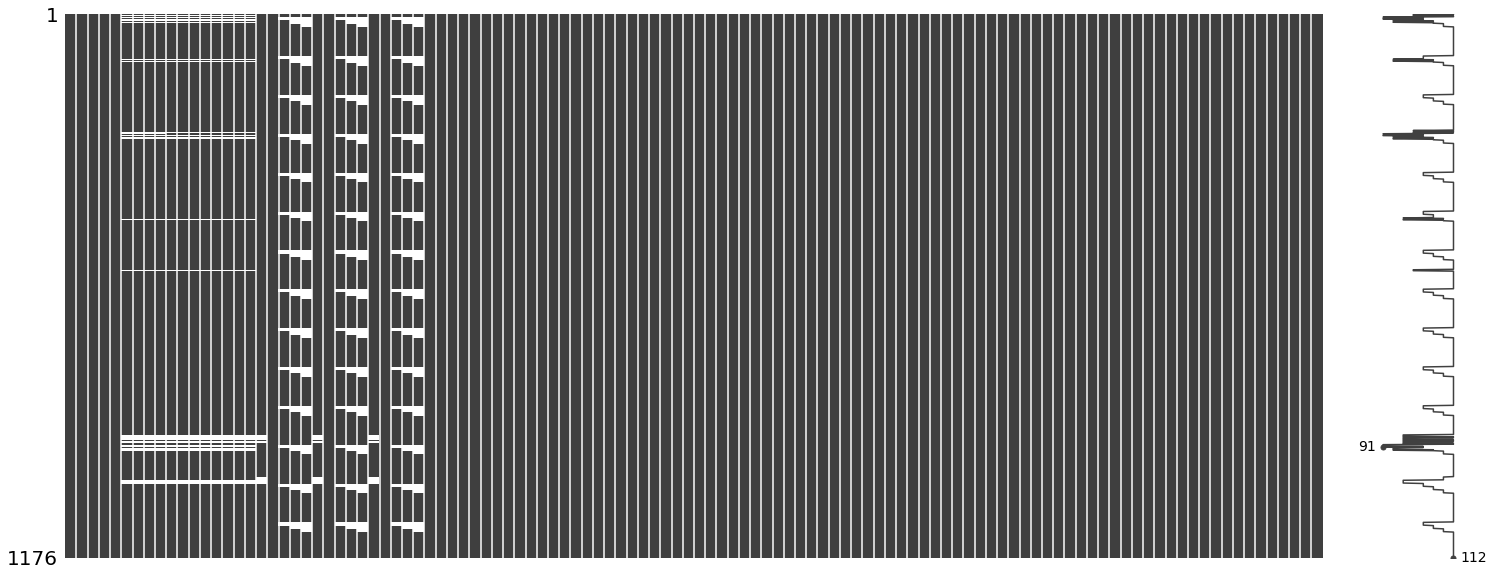

In [22]:
missingno.matrix(dataset_operational)

In [23]:
missing = describe_dataframe(dataset_operational, remove_zeros=True)
missing

,Column,Missing
0,ndvi,5.1020
1,ndmi,5.1020
2,ndwi,5.1020
3,ndbi,5.1020
4,ndvi_mean,5.0170
...,...,...
19,lst_apr_night_mean,25.0000
20,lst_mean,2.4660
21,lst_feb_mean,8.3333
22,lst_mar_mean,16.6667


<AxesSubplot:>

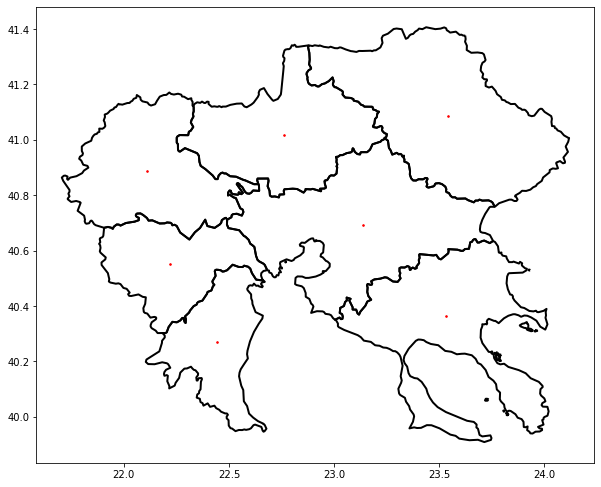

In [24]:
## Reading shapefiles from Greece

greece_nuts3_gdf = gpd.read_file(f"../../../../Europe NUTS - LAU/Greece/data/EL_Whole.shp",  encoding=enc)

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)

nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == f'{NUTS2_ID}']

nuts3_points = gpd.GeoDataFrame(dataset_monthly[['NUTS3_ID']], geometry=gpd.points_from_xy(dataset_monthly.x, dataset_monthly.y))

ax = nuts3_points.head(7).plot(markersize=2.5, figsize=(10, 10), color='red')
nuts3_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [25]:
dataset_operational.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_OP_2010_2023.csv", encoding = enc, index = False)